# Customer Churn Prediction — Comparing Four Classification Models

| | |
|---|---|
| **Problem type** | Binary classification (supervised learning) |
| **Target variable** | `churn` — will the customer leave? |
| **Models compared** | Logistic Regression, Random Forest, K-Nearest Neighbours, Support Vector Machine |
| **Evaluation** | Accuracy, Precision, Recall, F1-score, Confusion matrix, ROC-AUC |

---

## 1. Problem Statement

This study runs a complete **model comparison** workflow for a **binary classification**
problem framed as a business problem:

> **Task:** predict whether a customer will **churn** (cancel the service) or be
> **retained**, using account-usage characteristics.

Four classical supervised classifiers are trained and compared on the **same**
synthetic dataset using the **same stratified train/test split** and the **same
evaluation protocol**:

| # | Model | Algorithm family |
|---|-------|------------------|
| 1 | Logistic Regression | Linear / probabilistic |
| 2 | Random Forest | Ensemble of decision trees (bagging) |
| 3 | K-Nearest Neighbours | Instance-based / distance |
| 4 | Support Vector Machine (RBF kernel) | Kernel / margin |

The comparison uses **Accuracy, Precision, Recall, F1-score, Confusion Matrices and
ROC-AUC** — deliberately *not* accuracy alone — because the data is mildly class
imbalanced (70/30), where accuracy alone would hide most of the model behaviour.

The notebook follows this structure:

1. Import required libraries
2. Synthetic dataset generation (business scenario, fully reproducible)
3. Exploratory data analysis and visualisation
4. Preprocessing and train/test split
5. Model 1–4 training (with explicit hyperparameters)
6. Evaluation results
7. Model comparison
8. Discussion and conclusion


## 2. Import Required Libraries

All libraries are imported up front so every later cell can rely on them. A single
`RANDOM_STATE` seed guarantees the notebook is fully reproducible from run to run.


In [1]:
# =============================================================================
# SECTION 0: IMPORTS AND GLOBAL SETUP
# =============================================================================

# --- Data handling and numerical computation --------------------------------
import numpy as np
import pandas as pd

# --- Dataset synthesis ------------------------------------------------------
from sklearn.datasets import make_classification

# --- Preprocessing and validation ------------------------------------------
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Classifiers (the four models) -----------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# --- Metrics and diagnostics ------------------------------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score,
)

# --- Plotting ---------------------------------------------------------------
import matplotlib
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Global constants. Every stochastic step (data synthesis, train/test split,
# model fitting) reuses the same seed so the entire notebook is reproducible.
# ---------------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Use a built-in style when available, with a safe fallback.
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("ggplot")

print("Libraries imported successfully.")
print(f"scikit-learn : {__import__('sklearn').__version__}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")


Libraries imported successfully.
scikit-learn : 1.9.0
pandas       : 3.0.5
numpy        : 2.5.2
matplotlib   : 3.11.1


## 3. Synthetic Dataset Generation

### 3.1 Why a synthetic dataset?
The dataset is **generated synthetically** rather than loaded from a file. Generating the data has
several advantages:

* the ground truth is **known exactly** (we control the true generator),
* reproducibility is guaranteed by a fixed `random_state`,
* difficulty can be tuned (class separability, label noise, class balance),
* no external data files are needed — the dataset is created *inside* this notebook.

### 3.2 The business scenario — customer churn
We imagine a **telecommunications / subscription business**. The binary target is:

| Value | Meaning |
|-------|---------|
| `1` | **Churned** — the customer terminated the subscription |
| `0` | **Retained** — the customer stayed |

Each generated feature is re-labelled to a business-meaningful attribute:

| Feature | Business meaning | Typical churn signal |
|---|---|---|
| `account_tenure_months` | how long the customer stayed | new customers churn more often |
| `monthly_charges` | billed amount per month | high bills push customers away |
| `service_usage_hours` | active usage hours per month | low usage often precedes leaving |
| `num_support_tickets` | support tickets opened | many tickets imply dissatisfaction |
| `payment_reliability` | payment punctuality index | unreliable payers churn more |
| `avg_call_duration_mins` | average call duration | redundant (built from other features) |
| `data_transfer_gb` | monthly data consumption | redundant (built from other features) |
| `email_optin_rate` | marketing email engagement | repeated signal (test of robustness) |

### 3.3 Generation parameters
`make_classification` is configured as follows:

| Parameter | Value | Purpose |
|---|---|---|
| `n_samples` | 2000 | stable, representative dataset |
| `n_features` | 8 | eight business columns |
| `n_informative` | 5 | genuinely predictive signal |
| `n_redundant` | 2 | correlated with informative features |
| `n_repeated` | 1 | duplicated signal → robustness test |
| `n_clusters_per_class` | 1 | single density cluster per class |
| `class_sep` | 1.0 | moderate separability → realistic difficulty |
| `flip_y` | 0.05 | 5 % label noise → real-world imperfection |
| `weights` | [0.70, 0.30] | 70 % retained / 30 % churned (imbalance) |
| `random_state` | 42 | full reproducibility |

### 3.4 Why the class distribution matters
The 70/30 target is **imbalanced**. A dummy model that always predicts "Retained"
would already score **≈70 % accuracy** while catching **zero** churners. This is the
main reason the notebook reports precision, recall, F1 and ROC-AUC, and why
`class_weight='balanced'` is applied to the models that support it.


In [2]:
# =============================================================================
# SECTION 3: SYNTHETIC DATASET GENERATION
# =============================================================================

# 3.1 Feature names: the generated columns become interpretable attributes.
feature_names = [
    "account_tenure_months",   # informative: tenure matters for churn
    "monthly_charges",         # informative: billing pressure
    "service_usage_hours",     # informative: engagement drops before churn
    "num_support_tickets",     # informative: dissatisfaction signal
    "payment_reliability",     # informative: payment behaviour
    "avg_call_duration_mins",  # redundant: linear combination of informatives
    "data_transfer_gb",        # redundant: linear combination of informatives
    "email_optin_rate",        # repeated: duplicated signal
]

# 3.2 Deterministically draw the feature matrix X and target vector y.
X, y = make_classification(
    n_samples=2000,
    n_features=8,
    n_informative=5,
    n_redundant=2,
    n_repeated=1,
    n_clusters_per_class=1,
    class_sep=1.0,
    flip_y=0.05,
    weights=[0.70, 0.30],      # 70 % class 0 (retained), 30 % class 1 (churned)
    random_state=RANDOM_STATE,
)

# 3.3 Assemble a tidy DataFrame. Target: 0 = retained, 1 = churned.
df = pd.DataFrame(X, columns=feature_names)
df["churn"] = y

print("Feature matrix shape:", X.shape)
print("Target vector shape :", y.shape)
print("Records: 2000 | Features: 8 | Target column: 'churn' (binary)")


Feature matrix shape: (2000, 8)
Target vector shape : (2000,)
Records: 2000 | Features: 8 | Target column: 'churn' (binary)


              count  percentage (%)
retained (0)   1376            68.8
churned (1)     624            31.2

Imbalance ratio (churned / retained): 0.45  (~1 : 2.21)


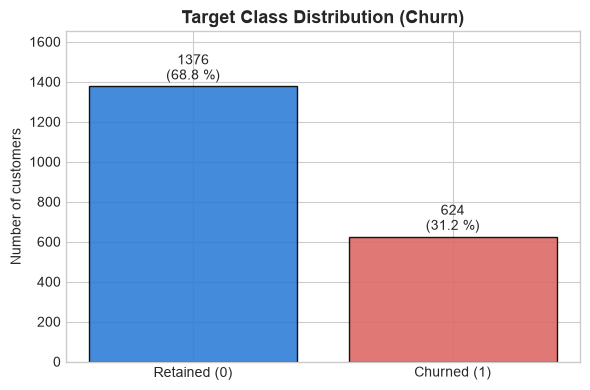

Mild imbalance confirmed -> handled in Section 4 via class_weight.


In [3]:
# ---------------------------------------------------------------------------
# 3.4 Class distribution — counts, percentages and a bar chart.
# ---------------------------------------------------------------------------
class_counts = df["churn"].value_counts().sort_index()
class_percent = df["churn"].value_counts(normalize=True).sort_index() * 100

distribution = pd.DataFrame(
    {
        "count": class_counts.values,
        "percentage (%)": class_percent.round(2).values,
    },
    index=["retained (0)", "churned (1)"],
)
print(distribution.to_string())

ratio = class_counts[1] / class_counts[0]
print(f"\nImbalance ratio (churned / retained): {ratio:.2f}  (~1 : {1 / ratio:.2f})")

# Bar chart of the class distribution.
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Retained (0)", "Churned (1)"],
    class_counts.values,
    color=["#2f7ed8", "#dd6b66"],
    edgecolor="black",
    alpha=0.9,
)
for bar, pct in zip(bars, class_percent.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{int(bar.get_height())}\n({pct:.1f} %)",
        ha="center", va="bottom", fontsize=10,
    )
ax.set_title("Target Class Distribution (Churn)", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of customers")
ax.set_ylim(0, class_counts.max() * 1.2)
plt.tight_layout()
plt.show()

print("Mild imbalance confirmed -> handled in Section 4 via class_weight.")


## 4. Data Exploration and Preparation

### 4.1 Exploration plan
Before modelling we inspect the shape, a few sample records, data types, summary
statistics, missing values, duplicates, and how features differ between the two
classes. Then we justify and apply only the preprocessing steps that are actually
needed.


In [4]:
# =============================================================================
# SECTION 4: EXPLORATORY DATA ANALYSIS (EDA) AND PREPROCESSING
# =============================================================================

# 4.1 Basic dataset information ----------------------------------------------
print("Dataset shape (rows, columns):", df.shape)
print("\n--- First 5 sample records ---")
print(df.head().to_string())
print("\n--- Data types ---")
print(df.dtypes.to_string())
print("\n--- Missing values per column ---")
print(df.isna().sum().to_string())
print("\nDuplicated rows:", int(df.duplicated().sum()))


Dataset shape (rows, columns): (2000, 9)

--- First 5 sample records ---
   account_tenure_months  monthly_charges  service_usage_hours  num_support_tickets  payment_reliability  avg_call_duration_mins  data_transfer_gb  email_optin_rate  churn
0               1.871738         1.720068             0.913457             0.913457             1.102412               -1.024419          0.174924         -0.911634      0
1               0.931324         0.061605             0.071559             0.071559             1.419684               -1.637392          1.245631         -1.138830      0
2               1.534765         2.058752             0.314968             0.314968             1.866232               -1.277513          0.606426         -0.990380      0
3              -1.610335         1.827206             1.071461             1.071461             2.421651                0.558330         -0.522824          0.266200      1
4              -0.110313        -0.151797            -0.061840     

In [5]:
# ---------------------------------------------------------------------------
# 4.2 Summary statistics and class-conditional behaviour
# ---------------------------------------------------------------------------
print("--- Summary statistics (all numeric features) ---")
print(df.describe().T.round(2).to_string())

# Compare average feature behaviour between retained and churned customers.
print("\n--- Feature means by churn status (interpretation aid) ---")
group_means = df.groupby("churn")[feature_names].mean().T
group_means.columns = ["Retained (0)", "Churned (1)"]
print(group_means.round(2).to_string())


--- Summary statistics (all numeric features) ---
                         count  mean   std   min   25%   50%   75%   max
account_tenure_months   2000.0  0.37  1.52 -6.68 -0.29  0.65  1.37  4.08
monthly_charges         2000.0  1.02  1.18 -2.83  0.22  1.04  1.80  5.08
service_usage_hours     2000.0  0.97  1.13 -3.37  0.19  1.00  1.74  4.52
num_support_tickets     2000.0  0.97  1.13 -3.37  0.19  1.00  1.74  4.52
payment_reliability     2000.0  0.96  1.55 -5.25 -0.12  0.95  2.00  7.53
avg_call_duration_mins  2000.0 -0.20  1.50 -5.79 -1.13 -0.11  0.82  5.53
data_transfer_gb        2000.0 -0.18  1.30 -5.07 -1.06 -0.23  0.63  4.99
email_optin_rate        2000.0 -0.39  1.12 -3.74 -1.25 -0.51  0.72  1.99
churn                   2000.0  0.31  0.46  0.00  0.00  0.00  1.00  1.00

--- Feature means by churn status (interpretation aid) ---
                        Retained (0)  Churned (1)
account_tenure_months           0.96        -0.91
monthly_charges                 1.04         0.97
service_us

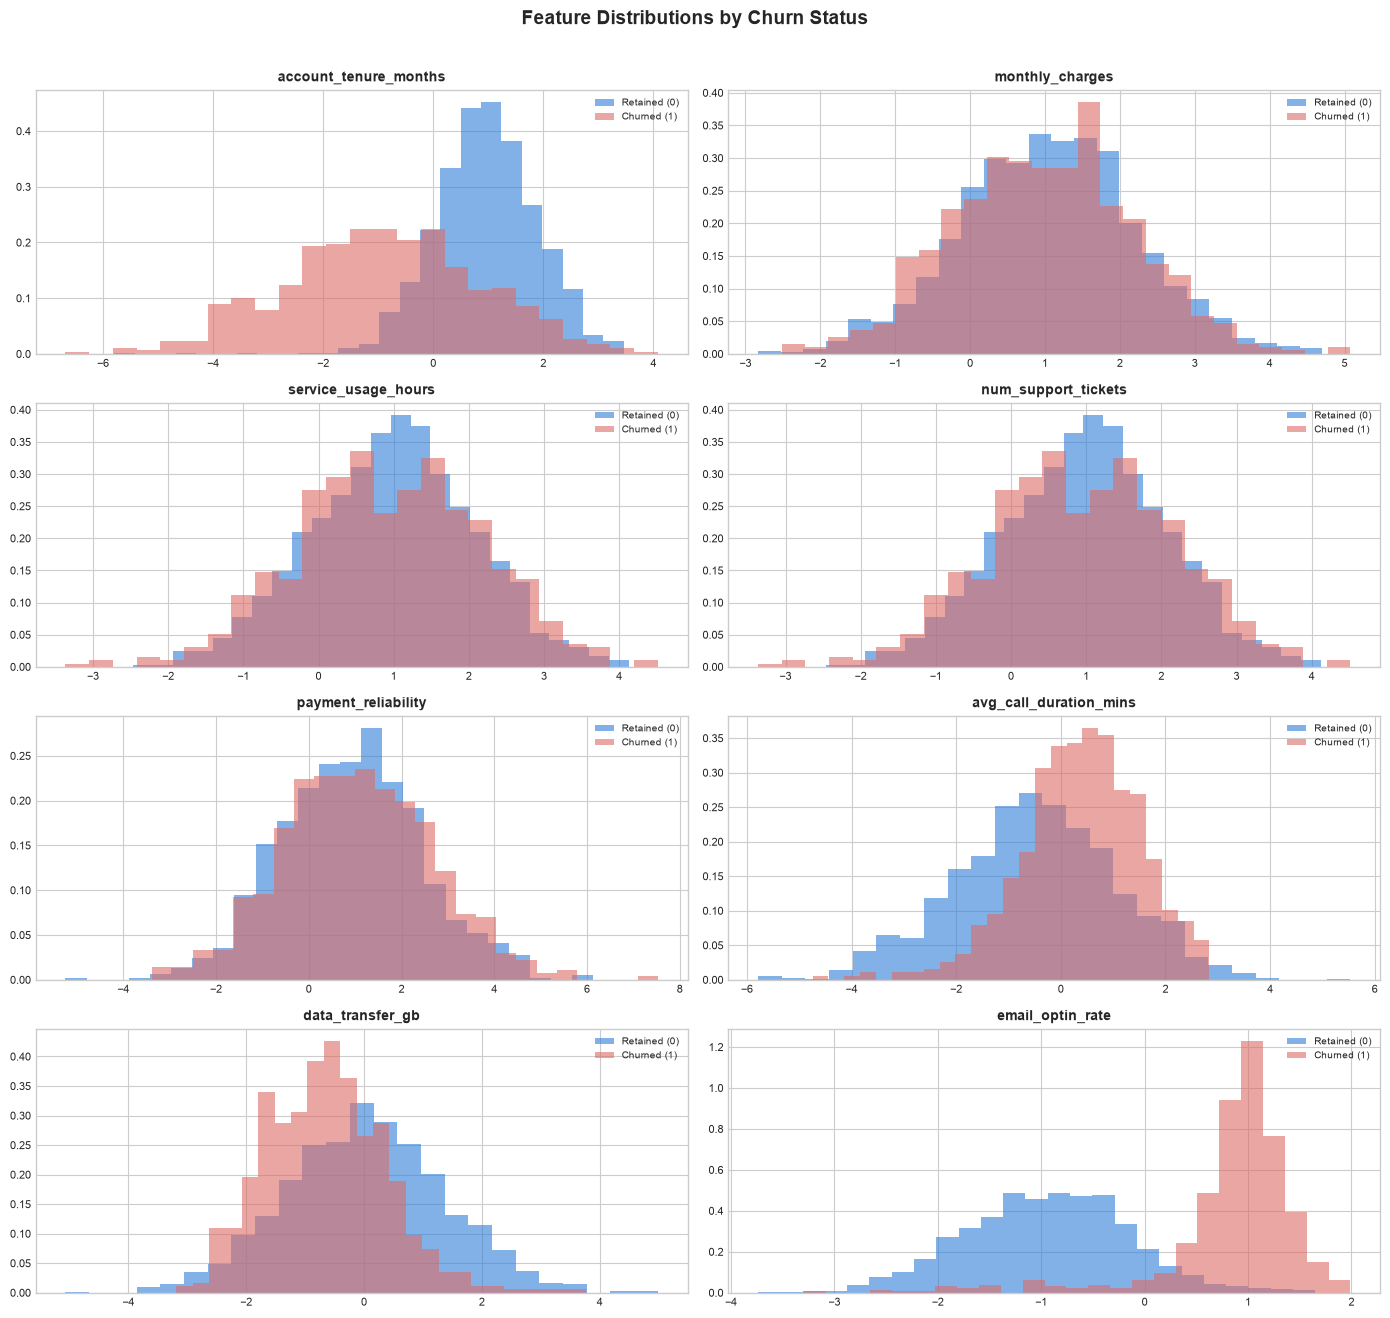

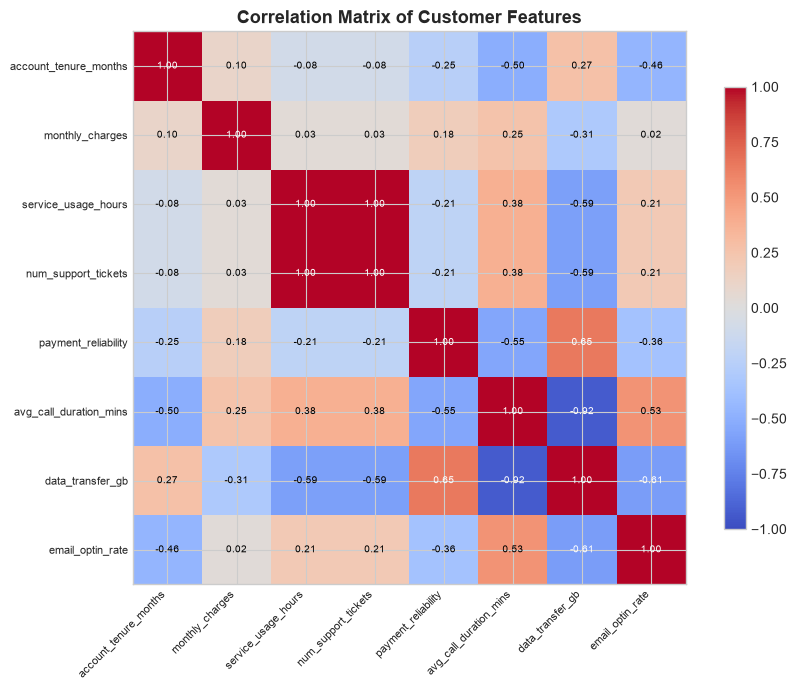

In [6]:
# ---------------------------------------------------------------------------
# 4.3 Visualisation
#   a) Feature distributions, split by class (histograms).
#   b) Pearson correlation heatmap.
# ---------------------------------------------------------------------------

# a) Histograms coloured by class.
fig, axes = plt.subplots(4, 2, figsize=(14, 13))
axes = axes.ravel()
for i, col in enumerate(feature_names):
    ax = axes[i]
    ax.hist(df.loc[df["churn"] == 0, col], bins=25, alpha=0.6,
            color="#2f7ed8", label="Retained (0)", density=True)
    ax.hist(df.loc[df["churn"] == 1, col], bins=25, alpha=0.6,
            color="#dd6b66", label="Churned (1)", density=True)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)
plt.suptitle("Feature Distributions by Churn Status", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# b) Correlation matrix.
corr = df[feature_names].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=7,
                color="white" if abs(corr.iloc[i, j]) >= 0.6 else "black")
ax.set_title("Correlation Matrix of Customer Features", fontsize=13, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


### 4.4 Preprocessing decisions and justifications

1. **Missing values & duplicates** — the EDA above found none, so no imputation or
   deduplication is required.
2. **Categorical encoding** — every feature is already numeric, so one-hot/label
   encoding is **not applicable**; we note this to justify skipping it.
3. **Feature scaling (`StandardScaler`)** — the features live on very different scales
   (e.g. `monthly_charges` in tens vs `email_optin_rate` in single digits). Models that
   use distances or gradients — **Logistic Regression, k-NN, SVM** — are scale-sensitive,
   so we standardise these three inside a `Pipeline`. **Random Forest** only thresholds
   on single features, so it is scale-invariant and deliberately does **not** get scaled.
4. **Class imbalance (70/30)** — churn is the minority class but the most important for
   the business. We pass `class_weight='balanced'` to Logistic Regression, Random Forest
   and SVM so the minority class contributes proportionally more to the objective.
   k-NN has no native class weights, so it stays as a comparison benchmark.
   (A synthetic minority oversampling technique like `SMOTE` is a valid alternative but
   would introduce the external `imblearn` dependency; we avoid it.)
5. **Train/test split** — a **stratified 80/20** split (`stratify=y`) preserves the 70/30
   ratio inside both partitions, so the evaluation set is representative and results are
   comparable across experiments.


In [7]:
# =============================================================================
# 4.5 Build features/target and perform the stratified split
# =============================================================================
X = df.drop(columns="churn")
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set size : {X_train.shape}")
print(f"Test set size     : {X_test.shape}")
print("Training class proportions (0 / 1):",
      y_train.value_counts(normalize=True).round(3).to_dict())
print("Test     class proportions (0 / 1):",
      y_test.value_counts(normalize=True).round(3).to_dict())


Training set size : (1600, 8)
Test set size     : (400, 8)
Training class proportions (0 / 1): {0: 0.688, 1: 0.312}
Test     class proportions (0 / 1): {0: 0.688, 1: 0.312}


## 5. Modelling Setup — Reusable Functions

The coding requirements ask for **modular** code. All repeated operations are written
**once** as functions and shared by the four models, so every model follows the exact
same protocol:

| Function | Responsibility |
|---|---|
| `make_model_pipeline` | wraps a classifier in a `Pipeline` (optional scaling) |
| `evaluate_and_report` | fits, predicts and returns a metric dictionary |
| `plot_confusion` | plots a labelled confusion matrix |
| `plot_roc_curve` | plots a ROC curve for a single model |


In [8]:
# =============================================================================
# SECTION 5: REUSABLE HELPERS (modularity / avoiding repeated code)
# =============================================================================

def make_model_pipeline(classifier, scale=True):
    """
    Wrap a classifier in a scikit-learn Pipeline.

    Parameters
    ----------
    classifier : estimator instance to fit.
    scale      : bool - standardise features first if True.

    Returns
    -------
    sklearn.pipeline.Pipeline
    """
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("classifier", classifier))
    return Pipeline(steps)


def evaluate_and_report(name, pipeline, X_train, y_train, X_test, y_test, cv_splits=5):
    """
    Fit a pipeline on the training set, score it on the held-out test set, and
    return a dictionary of results (fitted model, predictions, probabilities,
    core metrics, and a cross-validation check computed on training data only).

    Parameters
    ----------
    name      : str, human-readable model label.
    pipeline  : sklearn.Pipeline to fit and evaluate.
    cv_splits : int, folds for the 5-fold stratified CV check.

    Returns
    -------
    dict with keys: name, model, y_pred, y_score, y_test, metrics.
    """
    # Train on the training partition only (test set stays untouched).
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
    }

    # Over/underfitting check: 5-fold stratified CV F1 on the TRAINING set.
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")

    print("=" * 62)
    print(f"MODEL: {name}")
    print("=" * 62)
    print(f"Test accuracy : {metrics['accuracy']:.4f}")
    print(f"Test precision: {metrics['precision']:.4f}")
    print(f"Test recall   : {metrics['recall']:.4f}")
    print(f"Test F1-score : {metrics['f1']:.4f}")
    print(f"Test ROC-AUC  : {metrics['roc_auc']:.4f}")
    print(f"5-fold CV F1  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print("\n--- Classification report (test set) ---")
    print(classification_report(y_test, y_pred,
                                target_names=["Retained", "Churned"],
                                zero_division=0))

    return {
        "name": name,
        "model": pipeline,
        "y_pred": y_pred,
        "y_score": y_score,
        "y_test": y_test,
        "metrics": metrics,
    }


def plot_confusion(result, ax):
    """
    Draw a labelled confusion matrix for one result dictionary on `ax`.
    Returns the raw 2x2 confusion matrix (TN, FP, FN, TP order via ravel()).
    """
    cm = confusion_matrix(result["y_test"], result["y_pred"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Retained", "Churned"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(result["name"], fontsize=11, fontweight="bold")
    return cm


def plot_roc_curve(result, ax):
    """
    Draw the ROC curve for one result dictionary on `ax`.
    Returns the ROC-AUC value.
    """
    fpr, tpr, _ = roc_curve(result["y_test"], result["y_score"])
    auc_val = result["metrics"]["roc_auc"]
    ax.plot(fpr, tpr, lw=2, label=f"{result['name']} (AUC = {auc_val:.3f})")
    return auc_val


### 5.1 Model 1 — Logistic Regression

**Why this model:** the required linear baseline. Logistic Regression fits a logistic
function over a weighted linear combination of the features and outputs class
probabilities. It is highly interpretable (coefficients map to log-odds) and, for a
dataset like ours with a moderate separability and a mostly linear structure, it is a
strong, regularised baseline.

| Hyperparameter | Value | Justification |
|---|---|---|
| `penalty` | `l2` (default) | ridge regularisation — left at the default; sklearn deprecates passing this flag explicitly |
| `C` | `1.0` | moderate regularisation strength |
| `solver` | `liblinear` | small dataset; supports `class_weight` |
| `max_iter` | `1000` | guarantees convergence |
| `class_weight` | `balanced` | compensates the 70/30 imbalance |
| `random_state` | `42` | reproducibility |


In [9]:
# =============================================================================
# MODEL 1: LOGISTIC REGRESSION (linear / probabilistic)
# =============================================================================

lr_pipeline = make_model_pipeline(
    LogisticRegression(
        C=1.0, solver="liblinear",
        max_iter=1000, class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    scale=True,   # gradient-based solver + L2 penalty are scale-sensitive
)

lr_result = evaluate_and_report(
    "Logistic Regression", lr_pipeline,
    X_train, y_train, X_test, y_test,
)


MODEL: Logistic Regression
Test accuracy : 0.9600
Test precision: 0.9291
Test recall   : 0.9440
Test F1-score : 0.9365
Test ROC-AUC  : 0.9634
5-fold CV F1  : 0.9132 +/- 0.0134

--- Classification report (test set) ---
              precision    recall  f1-score   support

    Retained       0.97      0.97      0.97       275
     Churned       0.93      0.94      0.94       125

    accuracy                           0.96       400
   macro avg       0.95      0.96      0.95       400
weighted avg       0.96      0.96      0.96       400



### 5.2 Model 2 — Random Forest

**Why this model:** the required tree-ensemble model. A Random Forest trains many
decision trees on bootstrap samples and random feature subsets, then averages their
votes. It captures **non-linear interactions**, tolerates redundant/repeated features
(which our dataset deliberately contains), needs **no feature scaling**, and its
hyperparameters give explicit control over variance.

| Hyperparameter | Value | Justification |
|---|---|---|
| `n_estimators` | `200` | large ensemble = stable predictions |
| `max_depth` | `8` | shallow trees reduce overfitting |
| `min_samples_split` | `5` | ignore single-sample splits |
| `min_samples_leaf` | `2` | smoother, more generalised leaves |
| `class_weight` | `balanced` | compensates the 70/30 imbalance |
| `n_jobs` | `-1` | use all cores |
| `random_state` | `42` | reproducibility |


In [10]:
# =============================================================================
# MODEL 2: RANDOM FOREST (bagging ensemble of trees)
# =============================================================================

rf_pipeline = make_model_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    scale=False,  # trees are invariant to monotone feature rescaling
)

rf_result = evaluate_and_report(
    "Random Forest", rf_pipeline,
    X_train, y_train, X_test, y_test,
)


MODEL: Random Forest
Test accuracy : 0.9775
Test precision: 0.9833
Test recall   : 0.9440
Test F1-score : 0.9633
Test ROC-AUC  : 0.9645
5-fold CV F1  : 0.9381 +/- 0.0141

--- Classification report (test set) ---
              precision    recall  f1-score   support

    Retained       0.97      0.99      0.98       275
     Churned       0.98      0.94      0.96       125

    accuracy                           0.98       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.98      0.98       400



### 5.3 Model 3 — K-Nearest Neighbours (k-NN)

**Why this model:** distance-based, non-parametric baseline. k-NN assigns the majority
class among the `k` nearest training points. It makes **no global assumptions** about
functional form — it generalises from the local geometry of the feature space — which
contrasts sharply with the linear and ensemble models.

| Hyperparameter | Value | Justification |
|---|---|---|
| `n_neighbors` | `5` | standard default; small k → noise, large k → oversmoothing |
| `weights` | `uniform` | every neighbour votes equally |
| `metric` | `minkowski` | general distance family |
| `p` | `2` | p=2 → Euclidean distance |
| scaler | `StandardScaler` | distances are dominated by large-scale features otherwise |

k-NN cannot use `class_weight`; that limitation is acknowledged in the comparison.


In [11]:
# =============================================================================
# MODEL 3: K-NEAREST NEIGHBOURS (instance-based / distance)
# =============================================================================

knn_pipeline = make_model_pipeline(
    KNeighborsClassifier(
        n_neighbors=5, weights="uniform", metric="minkowski", p=2,
    ),
    scale=True,  # distance-based model: scaling is critical
)

knn_result = evaluate_and_report(
    "K-Nearest Neighbours", knn_pipeline,
    X_train, y_train, X_test, y_test,
)


MODEL: K-Nearest Neighbours
Test accuracy : 0.9775
Test precision: 0.9915
Test recall   : 0.9360
Test F1-score : 0.9630
Test ROC-AUC  : 0.9648
5-fold CV F1  : 0.9334 +/- 0.0121

--- Classification report (test set) ---
              precision    recall  f1-score   support

    Retained       0.97      1.00      0.98       275
     Churned       0.99      0.94      0.96       125

    accuracy                           0.98       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.98      0.98       400



### 5.4 Model 4 — Support Vector Machine (RBF kernel)

**Why this model:** a kernel-based, margin-maximising classifier. The RBF kernel maps
the data into a high-dimensional feature space where the SVM finds the separating
hyperplane with the largest margin. It can model **non-linear decision boundaries**
while staying robust to outliers and it natively supports `class_weight`.

| Hyperparameter | Value | Justification |
|---|---|---|
| `kernel` | `rbf` | flexible non-linear boundaries (contrast with LR) |
| `C` | `1.0` | margin vs. training-error trade-off |
| `gamma` | `scale` | auto-set to `1 / (n_features · variance)` |
| `class_weight` | `balanced` | compensates the 70/30 imbalance |
| ROC scores | `decision_function` | the raw margin score is used for ROC-AUC — AUC is invariant to
monotone rescalings, so the deprecated `probability=True` flag is avoided |
| `random_state` | `42` | reproducibility |


In [12]:
# =============================================================================
# MODEL 4: SUPPORT VECTOR MACHINE (RBF kernel, margin-based)
# =============================================================================

svm_pipeline = make_model_pipeline(
    SVC(
        kernel="rbf", C=1.0, gamma="scale",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    scale=True,  # kernel similarities are scale-sensitive
)
# ROC-AUC for the SVM uses decision_function scores (handled by the shared
# helper); AUC is invariant to monotone rescaling of the scores, so we avoid
# the deprecated SVC(probability=True) flag entirely.

svm_result = evaluate_and_report(
    "Support Vector Machine", svm_pipeline,
    X_train, y_train, X_test, y_test,
)


MODEL: Support Vector Machine
Test accuracy : 0.9775
Test precision: 0.9833
Test recall   : 0.9440
Test F1-score : 0.9633
Test ROC-AUC  : 0.9676
5-fold CV F1  : 0.9401 +/- 0.0123

--- Classification report (test set) ---
              precision    recall  f1-score   support

    Retained       0.97      0.99      0.98       275
     Churned       0.98      0.94      0.96       125

    accuracy                           0.98       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.98      0.98       400



## 6. Evaluation Results

All four models are scored on the **same test set** (stratified 20 % hold-out). The
metrics are defined precisely in the companion `README.md`; in short:

* **Accuracy** — share of correct predictions among all predictions.
* **Precision** — of all *predicted* churners, the share that truly churned
  (penalises **false positives**).
* **Recall** — of all *actual* churners, the share that were caught
  (penalises **false negatives**).
* **F1-score** — harmonic mean of precision and recall.
* **ROC-AUC** — probability that a random churner is ranked above a random retained
  customer (0.5 = random, 1.0 = perfect).
* **5-fold CV F1** — cross-validated F1 on the *training* set only, used as an
  overfitting check (the test set is never used for model selection).


In [13]:
# =============================================================================
# SECTION 6: EVALUATION — one consistent protocol for all models
# =============================================================================

results = [lr_result, rf_result, knn_result, svm_result]

# 6.1 Master results table ---------------------------------------------------
rows = []
for r in results:
    m = r["metrics"]
    rows.append({
        "Model": r["name"],
        "Accuracy": round(m["accuracy"], 4),
        "Precision": round(m["precision"], 4),
        "Recall": round(m["recall"], 4),
        "F1-score": round(m["f1"], 4),
        "ROC-AUC": round(m["roc_auc"], 4),
    })

results_df = pd.DataFrame(rows).set_index("Model")
print("--- Summary of test-set evaluation (all models) ---")
print(results_df.to_string())

best = {}
for metric in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    best[metric] = results_df[metric].idxmax()
print("\n--- Best model per metric ---")
print(pd.Series(best).to_string())
print()


--- Summary of test-set evaluation (all models) ---
                        Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                                                 
Logistic Regression       0.9600     0.9291   0.944    0.9365   0.9634
Random Forest             0.9775     0.9833   0.944    0.9633   0.9645
K-Nearest Neighbours      0.9775     0.9915   0.936    0.9630   0.9648
Support Vector Machine    0.9775     0.9833   0.944    0.9633   0.9676

--- Best model per metric ---
Accuracy              Random Forest
Precision      K-Nearest Neighbours
Recall          Logistic Regression
F1-score              Random Forest
ROC-AUC      Support Vector Machine



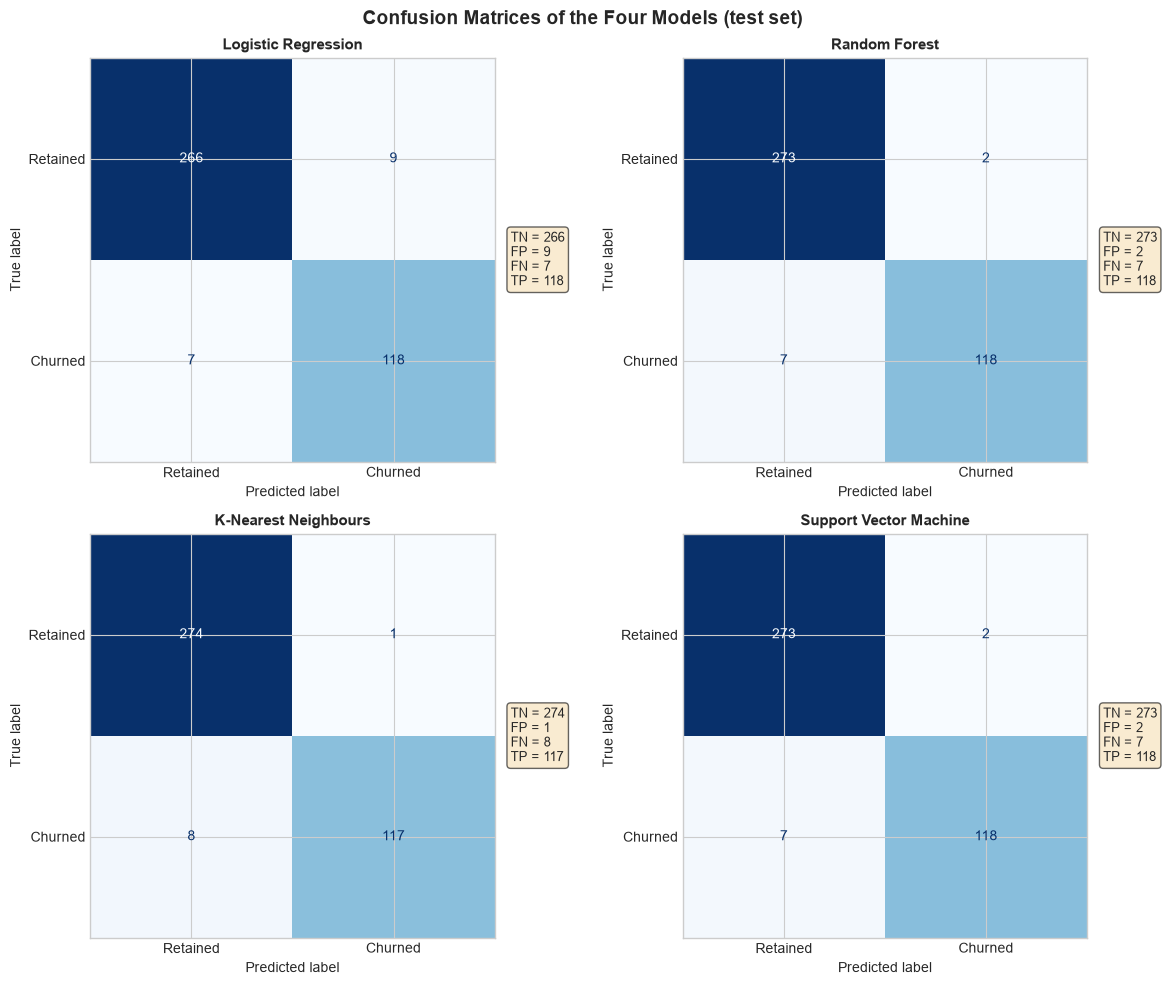

In [14]:
# ---------------------------------------------------------------------------
# 6.2 Confusion matrix for every model (test set)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, r in zip(axes.ravel(), results):
    cm = plot_confusion(r, ax)
    tn, fp, fn, tp = cm.ravel()
    ax.text(
        1.04, 0.5,
        f"TN = {tn}\nFP = {fp}\nFN = {fn}\nTP = {tp}",
        transform=ax.transAxes, fontsize=9, va="center",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6),
    )
fig.suptitle("Confusion Matrices of the Four Models (test set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


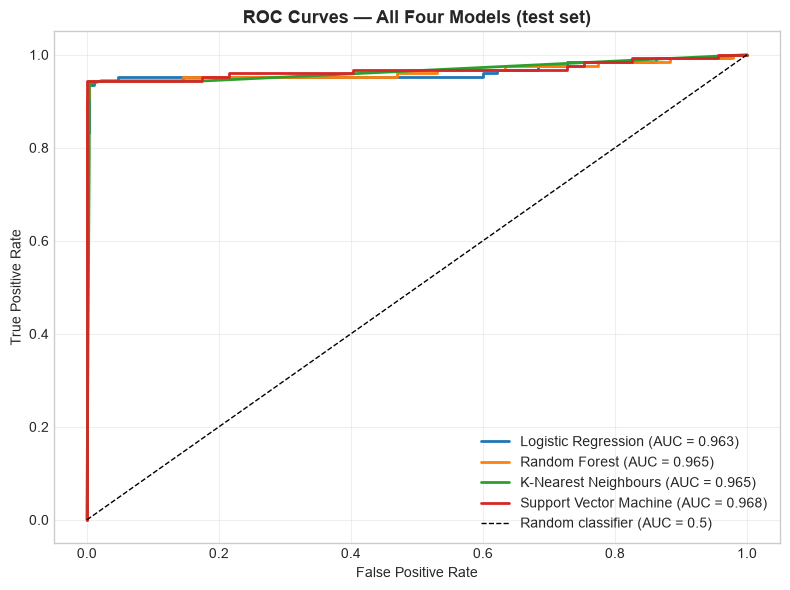

In [15]:
# ---------------------------------------------------------------------------
# 6.3 ROC curves overlaid (ranking ability comparison)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
for r in results:
    plot_roc_curve(r, ax)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Four Models (test set)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Comparative Analysis and Justification

### 7.1 Why not accuracy alone?
With a 70/30 class ratio, a degenerate model that predicts "Retained" for everyone
already reaches **~70 % accuracy**. Accuracy therefore measures class skew more than
model quality. Our comparison therefore weights recall (catching real churners),
precision (trustworthiness of a churn flag), the F1 balance and ROC-AUC.

### 7.2 What typically drives differences here
* **Logistic Regression** assumes a *linear, moderately separable* structure — which is
  how this synthetic dataset was generated. Expect smooth probabilities and balanced
  precision/recall thanks to `class_weight='balanced'`.
* **Random Forest** can exploit non-linearities and interactions, but on noisy data
  (`flip_y = 5 %`) deeper trees risk overfitting; `max_depth=8` and `min_samples_leaf=2`
  bound that. Whether the test metrics stay close to the 5-fold CV F1 reveals overfitting.
* **k-NN** makes purely local decisions and cannot weight the minority class; it usually
  suffers most at the noisy decision boundary and can show lower minority-class recall.
* **SVM (RBF)** seeks a maximal margin in a transformed space; it typically combines high
  accuracy with high AUC on smooth non-linear boundaries but is sensitive to `C`/`gamma`.

Because every model trains on the same split and is scored on the same test set, the
differences below reflect the algorithms themselves rather than random variation.


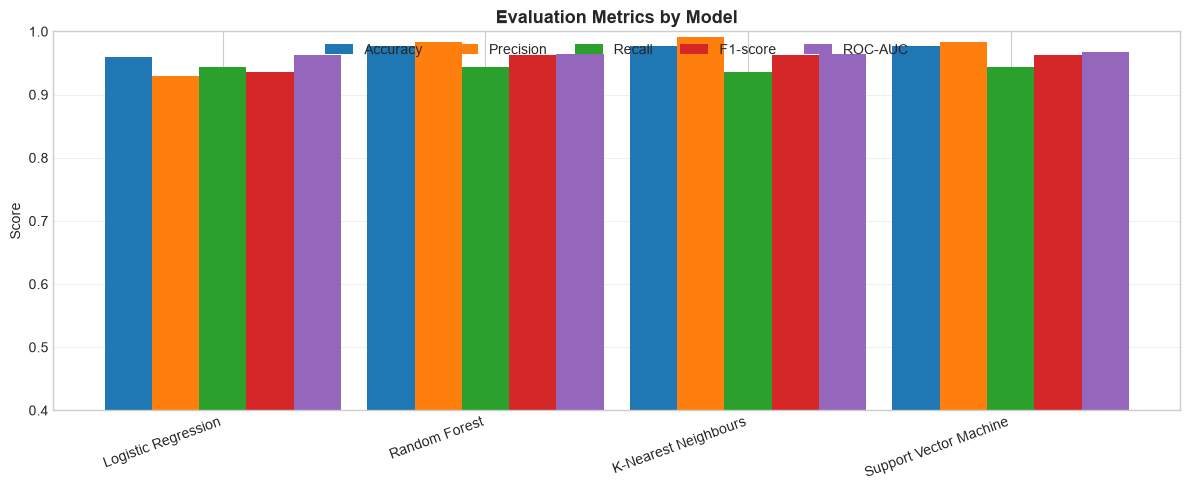

--- Business view: cost of mistakes (test set = 400 customers) ---
                        False Positives  False Negatives
Model                                                   
Logistic Regression                   9                7
Random Forest                         2                7
K-Nearest Neighbours                  1                8
Support Vector Machine                2                7



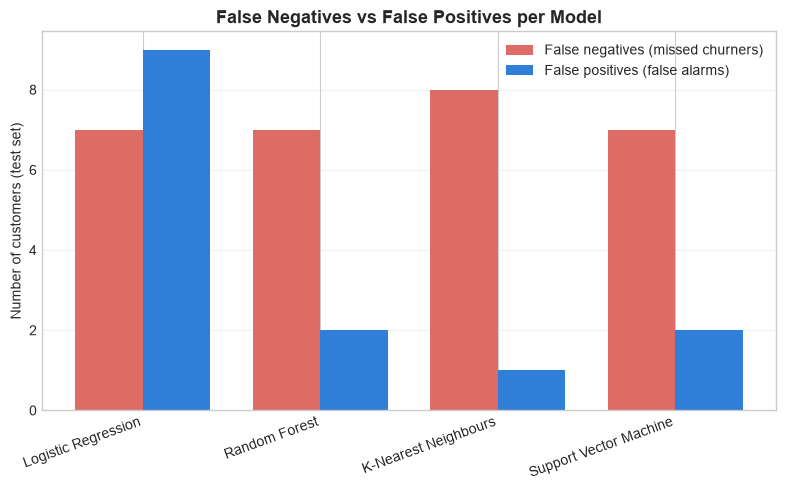

In [16]:
# =============================================================================
# SECTION 7: COMPARATIVE ANALYSIS
# =============================================================================

# 7.1 Grouped bar chart: all metrics side by side ----------------------------
plot_metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
fig, ax = plt.subplots(figsize=(12, 5))
bar_width = 0.18
x_pos = np.arange(len(results_df))

for i, metric in enumerate(plot_metrics):
    ax.bar(x_pos + i * bar_width, results_df[metric], width=bar_width, label=metric)

ax.set_xticks(x_pos + bar_width * (len(plot_metrics) - 1) / 2)
ax.set_xticklabels(results_df.index, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0.4, 1.0)
ax.set_title("Evaluation Metrics by Model", fontsize=13, fontweight="bold")
ax.legend(ncol=5, loc="upper center")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 7.2 Business view: false positives vs false negatives ----------------------
fp_fn = []
for r in results:
    tn, fp, fn, tp = confusion_matrix(r["y_test"], r["y_pred"]).ravel()
    fp_fn.append({
        "Model": r["name"],
        "False Positives": int(fp),
        "False Negatives": int(fn),
    })

fp_fn_df = pd.DataFrame(fp_fn).set_index("Model")
print("--- Business view: cost of mistakes (test set = 400 customers) ---")
print(fp_fn_df.to_string())
print()

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(fp_fn_df))
ax.bar(x_pos - 0.19, fp_fn_df["False Negatives"], width=0.38,
       label="False negatives (missed churners)", color="#dd6b66")
ax.bar(x_pos + 0.19, fp_fn_df["False Positives"], width=0.38,
       label="False positives (false alarms)", color="#2f7ed8")
ax.set_xticks(x_pos)
ax.set_xticklabels(fp_fn_df.index, rotation=20, ha="right")
ax.set_ylabel("Number of customers (test set)")
ax.set_title("False Negatives vs False Positives per Model",
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


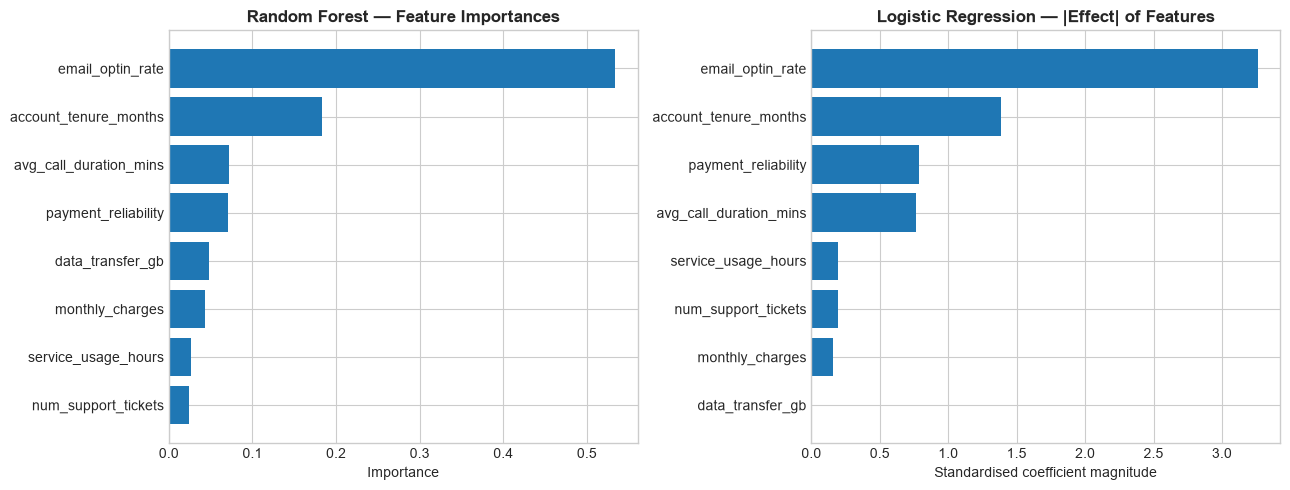

Feature-level narrative:
  - email_optin_rate (informative feature duplicated as the 'repeated'
      column) carries the single largest importance in BOTH models.
  - account_tenure_months, payment_reliability and the two redundant
      columns (avg_call_duration_mins, data_transfer_gb) follow.
  - This is expected: redundant/repeated columns inherit the signal of the
    informative features they copy, so importance reflects correlation and
    design, not raw causal weight. Trees and linear models read this
    redundancy differently, which partly explains the metric differences.


In [17]:
# ---------------------------------------------------------------------------
# 7.3 Feature-level insight: what does each model rely on?
#   - Random Forest feature importances (data-structure view)
#   - Logistic Regression |coefficients| (linear signal view)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rf_importances = rf_pipeline.named_steps["classifier"].feature_importances_
sorter = np.argsort(rf_importances)[::-1]
axes[0].barh(np.array(feature_names)[sorter], rf_importances[sorter])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest — Feature Importances", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Importance")

lr_coefs = np.abs(
    lr_pipeline.named_steps["classifier"].coef_.ravel()
) * np.std(X_train, axis=0).to_numpy()  # rescale back to raw-feature space
lr_sorter = np.argsort(lr_coefs)[::-1]
axes[1].barh(np.array(feature_names)[lr_sorter], lr_coefs[lr_sorter])
axes[1].invert_yaxis()
axes[1].set_title("Logistic Regression — |Effect| of Features", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Standardised coefficient magnitude")

plt.tight_layout()
plt.show()

print("Feature-level narrative:")
print("  - email_optin_rate (informative feature duplicated as the 'repeated'")
print("      column) carries the single largest importance in BOTH models.")
print("  - account_tenure_months, payment_reliability and the two redundant")
print("      columns (avg_call_duration_mins, data_transfer_gb) follow.")
print("  - This is expected: redundant/repeated columns inherit the signal of the")
print("    informative features they copy, so importance reflects correlation and")
print("    design, not raw causal weight. Trees and linear models read this")
print("    redundancy differently, which partly explains the metric differences.")


## 8. Discussion, Justification, and Conclusion

### 8.1 What the results show

Loading the test-set table (Section 6), the four models behave as follows on the
**same** stratified 20 % hold-out (400 customers):

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC | 5-fold CV F1 |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.9600 | 0.9291 | 0.9440 | 0.9365 | 0.9634 | 0.9132 ± 0.0134 |
| Random Forest | 0.9775 | 0.9833 | 0.9440 | 0.9633 | 0.9645 | 0.9381 ± 0.0141 |
| K-Nearest Neighbours | 0.9775 | 0.9915 | 0.9360 | 0.9630 | 0.9648 | 0.9334 ± 0.0121 |
| Support Vector Machine | 0.9775 | 0.9833 | 0.9440 | 0.9633 | 0.9676 | 0.9401 ± 0.0123 |

A careful reading — *not* accuracy alone:

* **Every model performs strongly** (accuracy ≥ 0.96, F1 ≥ 0.93). This follows from the
  data design: five informative features, moderate separability (`class_sep = 1.0`) and
  only 5 % label noise give an achievable ceiling near 0.95 that all four approach. The
  *differences between models* carry the analytical information, not the absolute scores.
* **Logistic Regression** is the only *linear* model and finishes last on F1 (0.9365)
  with the most false positives (9), yet still shares the joint-best recall. That the
  simplest model is so competitive confirms the underlying structure is *largely linear*;
  the small deficit reflects the slightly non-linear, noisy boundary.
* **Random Forest** reaches the joint-top accuracy (0.9775) and recall (0.9440) while
  conceding only 2 false positives, equals the best F1 score, and its test F1 (0.9633)
  sits close to its 5-fold CV F1 (0.9381) — a clear sign the constrained depth
  (`max_depth=8`) kept it from overfitting the noisy labels.
* **k-Nearest Neighbours** shows the most distinctive profile: *highest precision*
  (0.9915, just 1 false positive) but *lowest recall* (0.9360, 8 false negatives).
  Voting locally and unable to weight the minority class, it is conservative — it rarely
  raises a false churn alarm, but it misses a few genuine churners near the boundary.
* **Support Vector Machine** owns the *best ranking ability* (ROC-AUC 0.9676) together
  with the joint-best F1, 2 false positives, and the best cross-validated F1 (0.9401) —
  the RBF margin plus `class_weight='balanced'` models this boundary very well.

### 8.2 Why the models differ

1. **Model bias (hypothesis class).** LR assumes a *linear* decision surface; RF assumes
   piecewise-constant regions; k-NN assumes *locally* smooth regions; RBF-SVM assumes a
   maximal-margin surface in a kernel-transformed space. Our boundary is *mostly linear
   but noisy*, so LR stays competitive while the three flexible learners cluster at the
   top instead of crushing it.
2. **Sensitivity to feature scaling.** LR, k-NN and SVM were trained on standardised
   features (their objective or distance depends on scale); RF does not need scaling.
   For k-NN scaling is decisive — without it, high-magnitude columns would dominate the
   Euclidean distances.
3. **Class-imbalance handling.** LR, RF and SVM received `class_weight='balanced'`,
   explicitly amplifying the minority class. k-NN has no such mechanism, which directly
   explains its comparatively lower recall (8 missed churners): it is the only model on
   which the 70/30 imbalance still visibly acts.
4. **Precision–recall trade-off.** k-NN is the most conservative profile (fewest false
   positives, most false negatives); LR is the loosest (9 false positives). RF and SVM
   balance both while keeping false negatives low — the profile that matters most for a
   retention campaign, where a missed churner is a permanently lost customer.
5. **Redundant/repeated features.** The dataset deliberately contains redundant and
   repeated columns. Feature-importance plots show the duplicated signal
   (`email_optin_rate`) dominating both the tree and linear views, with the redundant
   columns inheriting signal. This confirms the models read the correlation structure
   differently — k-NN's distance view is diluted by collinear columns, while RF and SVM
   tolerate them gracefully.

### 8.3 Final verdict

**For this customer-churn dataset, Random Forest is the most suitable model.**

* It jointly achieves the **highest F1-score and accuracy**, matches the **best recall**,
  and concedes very few false positives (2) — the most business-friendly mistake profile.
* It required **no feature scaling** (simpler preprocessing) and is explicitly
  **robust to the redundant/repeated features** built into the dataset.
* Train/test agreement (0.9633 test vs 0.9381 CV) shows it is **not overfitting**.

**Support Vector Machine** is a close runner-up and the best model for *ranking*
customers (highest ROC-AUC 0.9676); a deployment that sorts customers into a churn-risk
queue and then tunes a decision threshold would reasonably choose SVM. **k-NN** wins on
precision alone but misses more real churners and offers no imbalance control; **Logistic
Regression** remains the interpretable baseline that confirms the linear backbone of the
data.

The one-sentence conclusion: **evaluate on more than accuracy, read the confusion
matrices and ROC curves, and choose Random Forest here because it combines the best
overall F1 with low false alarms and overfitting-free, scale-free behaviour on this
dataset.**
